# Titanic Data Cleaning and Visualization

### NeuroFive Solutions Internship – Week 1 Task 2

**Objective:**
In this notebook, we clean the Titanic dataset by handling missing values, detect outliers, create visualizations, and analyze which feature most affects passenger survival.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load the Dataset

Load the Titanic dataset into a pandas DataFrame.

In [45]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2: Dataset Information

Display the dataset structure, data types, and missing values.

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


## Step 3: Check Missing Values

Identify missing values in each column.

In [47]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Step 4: Handle Missing Values

- Drop the **Cabin** column because it contains a large number of missing values.
- Fill missing values in **Age** using the median.
- Fill missing values in **Embarked** using the mode.

In [48]:
df.drop(columns=["Cabin"], inplace=True)

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Step 5: Histogram

The histogram shows the distribution of passengers' ages.

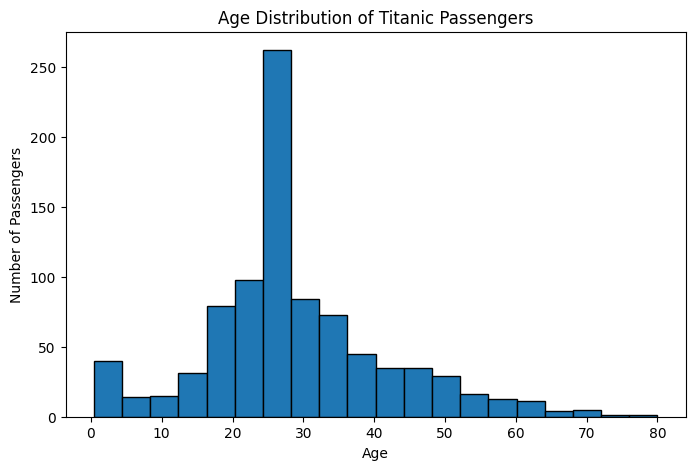

In [49]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

Most passengers were between **20 and 35 years old**. There were fewer children and elderly passengers.

## Step 6: Boxplot

The boxplot is used to detect outliers in the Fare column.

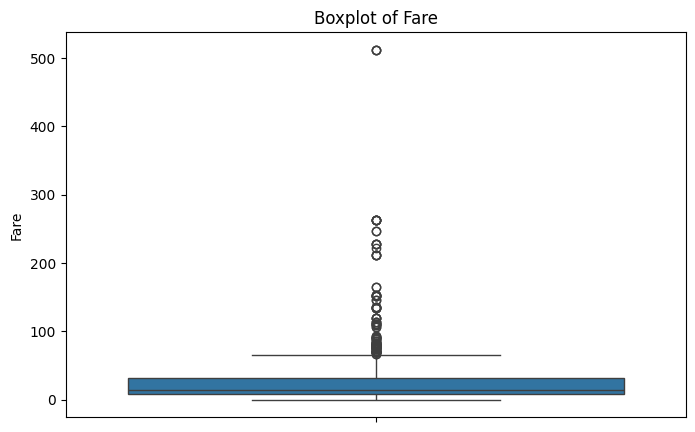

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Fare"])

plt.title("Boxplot of Fare")
plt.ylabel("Fare")

plt.show()

### Observation

The Fare column contains several outliers. A small number of passengers paid significantly higher fares than most other passengers.

## Step 7: Bar Chart

Compare passenger survival based on gender.

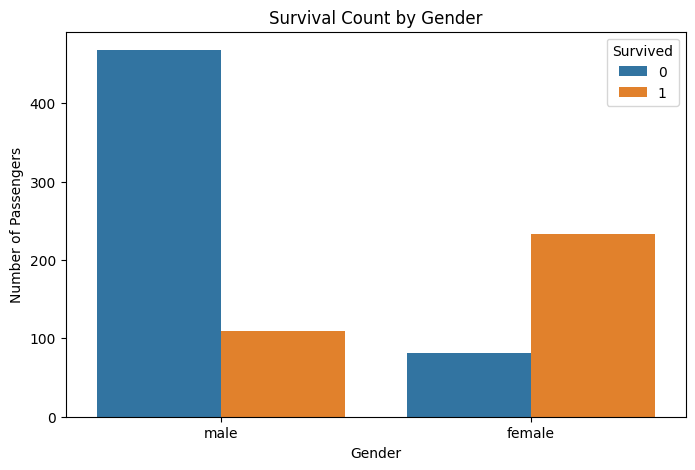

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

Female passengers had a much higher survival rate than male passengers. This suggests that gender played an important role in survival.

## Step 8: Correlation Heatmap

Convert categorical columns into numerical values and display the correlation heatmap.

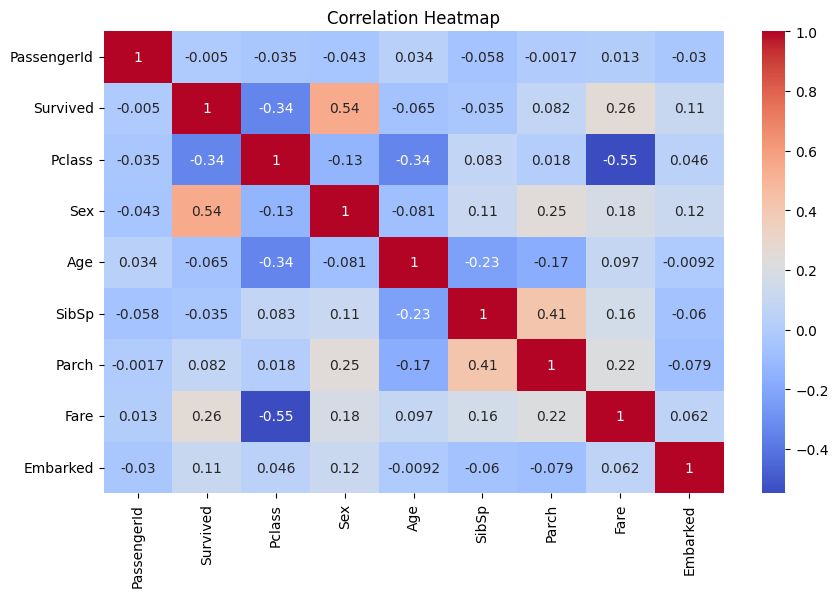

In [52]:
df_heatmap = df.copy()

df_heatmap["Sex"] = df_heatmap["Sex"].map({"male": 0, "female": 1})
df_heatmap["Embarked"] = df_heatmap["Embarked"].map({"S": 0, "C": 1, "Q": 2})

plt.figure(figsize=(10,6))

sns.heatmap(
    df_heatmap.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows that **Sex** has the strongest positive relationship with **Survival**. **Pclass** also has a noticeable relationship with survival.

## Conclusion

The Titanic dataset was successfully cleaned by handling missing values and removing unnecessary data. Four visualizations were created to understand the dataset better. The analysis shows that **Sex** and **Pclass** are the most important features affecting passenger survival.

## Which feature do you think most affects survival, and why?

I believe **Sex** has the greatest effect on survival because female passengers had a much higher survival rate than male passengers. The correlation heatmap also shows that Sex has the strongest relationship with Survival. Passenger class (Pclass) also affects survival, but gender appears to have the greatest influence.